In [2]:
!pip install catboost scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import os


from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [4]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current directory:
/content

Files in current directory:
['.config', 'sample_data']


In [6]:
import pandas as pd

train = pd.read_csv("/content/dataset_C_training.csv")
test = pd.read_csv("/content/dataset_C_testing.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (4756, 31)
Test Shape: (4749, 30)


In [7]:
train.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [8]:
missing = train.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

,0
employment_sector,2330
health_insurance,1908
income_poverty,748
rent_or_own,329
employment_status,238
marital_status,231
education,228
chronic_med_condition,169
child_under_6_months,135
health_worker,132


In [9]:
train["covid_vaccine"].value_counts()

,count
covid_vaccine,
0,3202
1,1554


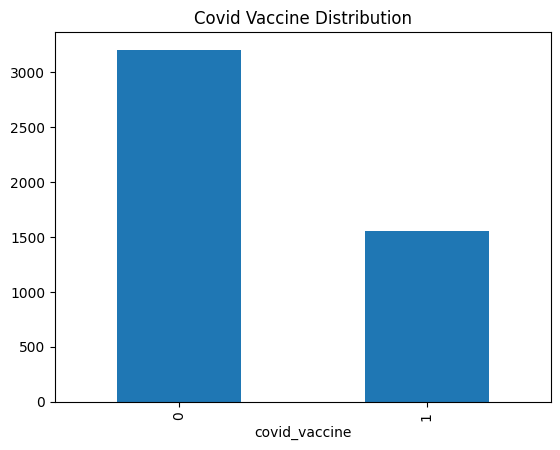

In [10]:
train["covid_vaccine"].value_counts().plot(
    kind="bar"
)

plt.title("Covid Vaccine Distribution")
plt.show()

In [11]:
for df in [train, test]:

    df["behavior_score"] = (
        df["behavioral_avoidance"].fillna(0)
        + df["behavioral_face_mask"].fillna(0)
        + df["behavioral_wash_hands"].fillna(0)
        + df["behavioral_large_gatherings"].fillna(0)
        + df["behavioral_outside_home"].fillna(0)
        + df["behavioral_touch_face"].fillna(0)
    )

    df["risk_score"] = (
        df["covid_concern"].fillna(0)
        + df["opinion_covid_risk"].fillna(0)
    )

    df["vaccine_confidence"] = (
        df["opinion_covid_vacc_effective"].fillna(0)
        - df["opinion_covid_sick_from_vacc"].fillna(0)
    )

In [12]:
TARGET = "covid_vaccine"

X = train.drop(columns=[TARGET])

y = train[TARGET]

In [13]:
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print(cat_features)

['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [14]:
# Find categorical columns
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

# Convert categorical columns to string
for col in cat_features:
    X[col] = X[col].fillna("Unknown").astype(str)
    test[col] = test[col].fillna("Unknown").astype(str)

print(cat_features)

['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [15]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)

(3804, 33)
(952, 33)


In [16]:
model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    eval_metric="AUC",
    loss_function="Logloss",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	test: 0.8427572	best: 0.8427572 (0)	total: 56.5ms	remaining: 1m 53s
100:	test: 0.8601462	best: 0.8601462 (100)	total: 1.18s	remaining: 22.1s
200:	test: 0.8644351	best: 0.8644903 (198)	total: 2.4s	remaining: 21.5s
300:	test: 0.8652226	best: 0.8652226 (300)	total: 3.31s	remaining: 18.7s
400:	test: 0.8643498	best: 0.8653029 (306)	total: 4.21s	remaining: 16.8s
500:	test: 0.8635623	best: 0.8653029 (306)	total: 5.14s	remaining: 15.4s
600:	test: 0.8624436	best: 0.8653029 (306)	total: 6.05s	remaining: 14.1s
700:	test: 0.8618918	best: 0.8653029 (306)	total: 6.97s	remaining: 12.9s
800:	test: 0.8611795	best: 0.8653029 (306)	total: 7.93s	remaining: 11.9s
900:	test: 0.8609438	best: 0.8653029 (306)	total: 8.87s	remaining: 10.8s
1000:	test: 0.8602967	best: 0.8653029 (306)	total: 9.79s	remaining: 9.78s
1100:	test: 0.8595242	best: 0.8653029 (306)	total: 10.7s	remaining: 8.76s
1200:	test: 0.8590125	best: 0.8653029 (306)	total: 11.8s	remaining: 7.82s
1300:	test: 0.8592432	best: 0.8653029 (306)	total: 

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=2000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [17]:
valid_preds = model.predict_proba(X_valid)[:,1]

auc = roc_auc_score(
    y_valid,
    valid_preds
)

print("Validation AUC:", auc)

Validation AUC: 0.8653029079362532


In [18]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
25,doctor_recc_covid,14.776154
13,health_insurance,14.584021
27,opinion_covid_risk,10.326710
26,opinion_covid_vacc_effective,7.456325
29,employment_sector,5.104458
14,age_group,4.611926
31,risk_score,4.308457
15,education,3.997135
2,covid_knowledge,3.127668
12,health_worker,3.044331


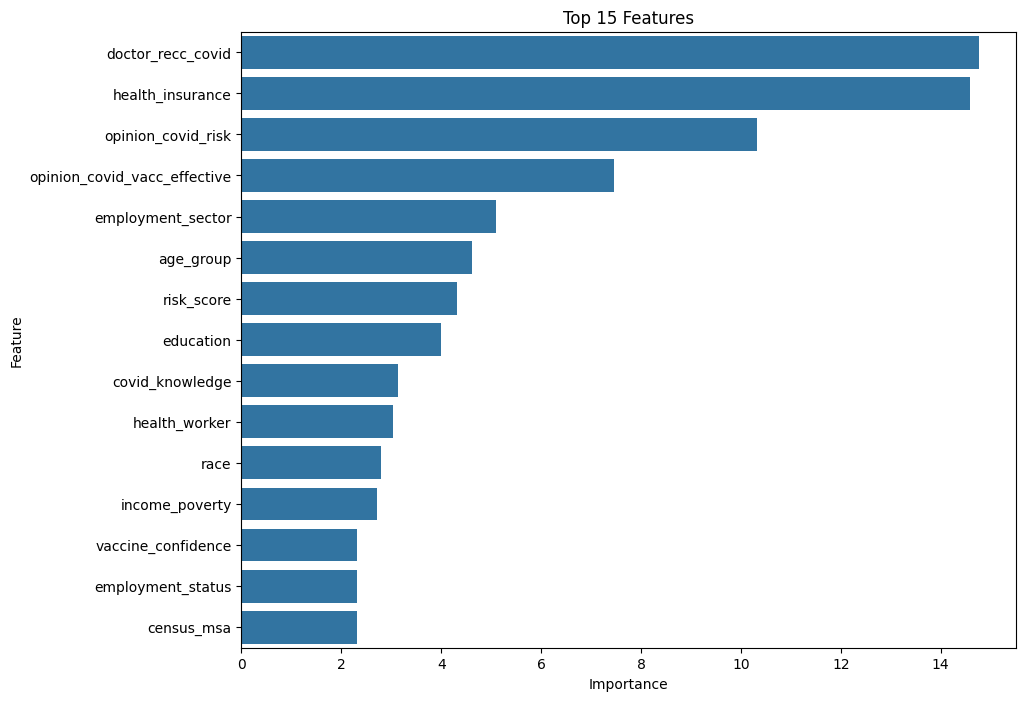

In [19]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features")
plt.show()

In [20]:
final_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

final_model.fit(
    X,
    y,
    cat_features=cat_features
)

0:	total: 10.7ms	remaining: 21.3s
100:	total: 920ms	remaining: 17.3s
200:	total: 1.88s	remaining: 16.8s
300:	total: 2.83s	remaining: 16s
400:	total: 3.81s	remaining: 15.2s
500:	total: 5.14s	remaining: 15.4s
600:	total: 6.44s	remaining: 15s
700:	total: 7.54s	remaining: 14s
800:	total: 9.11s	remaining: 13.6s
900:	total: 10.4s	remaining: 12.7s
1000:	total: 11.4s	remaining: 11.4s
1100:	total: 12.5s	remaining: 10.2s
1200:	total: 13.5s	remaining: 8.97s
1300:	total: 14.5s	remaining: 7.81s
1400:	total: 15.6s	remaining: 6.65s
1500:	total: 17.1s	remaining: 5.69s
1600:	total: 18.3s	remaining: 4.57s
1700:	total: 19.4s	remaining: 3.4s
1800:	total: 20.4s	remaining: 2.26s
1900:	total: 21.5s	remaining: 1.12s
1999:	total: 22.5s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=2000, learning_rate=0.03, random_seed=42, verbose=100)

In [21]:
test_preds = final_model.predict_proba(test)[:,1]

In [22]:
CatBoostValues = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "covid_vaccine": test_preds
})

CatBoostValues.head()

,respondent_id,covid_vaccine
0,4757,0.173276
1,4758,0.068049
2,4759,0.229154
3,4760,0.201100
4,4761,0.013349


In [23]:
CatBoostValues.to_csv(
    "CatBoostValues.csv",
    index=False
)

print("CatBoostValues Saved")

CatBoostValues Saved


In [24]:
pd.read_csv("CatBoostValues.csv").head()

,respondent_id,covid_vaccine
0,4757,0.173276
1,4758,0.068049
2,4759,0.229154
3,4760,0.201100
4,4761,0.013349


In [27]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

valid_preds_proba = model.predict_proba(X_valid)[:, 1]

valid_preds_labels = (valid_preds_proba >= 0.5).astype(int)

accuracy = accuracy_score(y_valid, valid_preds_labels)
precision = precision_score(y_valid, valid_preds_labels)
f1 = f1_score(y_valid, valid_preds_labels)
roc_auc = roc_auc_score(y_valid, valid_preds_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.8130
Precision: 0.7608
F1 Score:  0.6855
ROC-AUC:   0.8653
